In [1]:
import functools
import warnings

import botocore
import boto3
from iterpop import iterpop as ip
from matplotlib.markers import MarkerStyle
from matplotlib.ticker import MultipleLocator
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import pandas as pd
from pandas.util import hash_pandas_object
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm

from dishpylib.pyhelpers import fit_control_t_distns

warnings.filterwarnings("ignore")


In [2]:
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervm7g52i
interpreter: 3.10.12 (main, Jul 15 2026, 23:40:17) [GCC 11.4.0]
notebook name: 2026-06-22-eco-gwas-nobb
notebook path: /home/runner/work/oee4/oee4/binder/2026-06-22-eco-gwas-nobb.ipynb
revision: bdac574
timestamp: 2026-09-21T22:20:08Z00:00

IPython==7.16.1
packaging==26.2


In [4]:
teeplot_subdir = "2026-06-22-eco-gwas-nobb"


In [5]:
@functools.lru_cache
def get_control_t_distns( bucket, prefix, suffix, endeavor, stint ):

    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    control_competitions, = bucket_handle.objects.filter(
        Prefix=f'endeavor={endeavor}/{prefix}control-competitions-highestroot{suffix}/stage={4 + bool(prefix)}+what=collated/stint={stint}/',
    )

    control_df = pd.read_csv(
        f's3://{bucket}/{control_competitions.key}',
    )

    return fit_control_t_distns(control_df[
        control_df["Root ID"].isin([0, 1])
    ].copy())


In [6]:
def preprocess_competition_fitnesses(competitions_df, control_fits_df):
    print(len(competitions_df), "competitions to preprocess")
    print(len(control_fits_df), "control fits available")
    # preprocess data
    @functools.lru_cache
    def h0_fit(series):
        return ip.popsingleton(
            control_fits_df[control_fits_df["Series"] == series].to_dict(
                orient="records",
            )
        )

    competitions_df["p"] = competitions_df.apply(
        lambda row: scipy_stats.t.cdf(
            row["Fitness Differential"],
            h0_fit(row["genome series"])["Fit Degrees of Freedom"],
            loc=h0_fit(row["genome series"])["Fit Loc"],
            scale=h0_fit(row["genome series"])["Fit Scale"],
        ),
        axis=1,
    )
    competitions_df["Is Less Fit"] = competitions_df["p"] < 1.0 / 40
    competitions_df["Is More Fit"] = competitions_df["p"] > (1.0 -  1.0 / 40)
    competitions_df["Is Neutral"] = ~(
        competitions_df["Is Less Fit"] | competitions_df["Is More Fit"]
    )
    competitions_df["Relative Fitness"] = competitions_df.apply(
        lambda row: (
            "Significantly Advantageous"
            if row["Is More Fit"]
            else (
                "Significantly Deleterious" if row["Is Less Fit"] else "Neutral"
            )
        ),
        axis=1,
    )

    return competitions_df


# get data


In [7]:
bucket = "prq49"
dfs = []
for suffix in [
    # "cryptic-",
    "-backgroundbb",
    "-nobb",

]:
    prefix = ""
    if "step" in bucket:
        step = int(bucket.split("-step")[-1]) + 1
    else:
        step = 0
    if "restint" in bucket:
        kind = bucket.split("-")[3]
    else:
        kind = None
    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    for stint in tqdm([100]):
        try:
            series_profiles, = bucket_handle.objects.filter(
                Prefix=f'endeavor=16/{prefix}variant-competitions-highestroot{suffix}/stage=4+what=collated/stint={stint}/',
            )
            import warnings
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
            control_fits_df = get_control_t_distns(bucket, prefix, suffix, 16, stint)
            df = pd.read_csv(
                f's3://{bucket}/{series_profiles.key}',
                compression='xz',
            )
            # df = df[df["Competition Series"] == 16005]
            # df = df.groupby([
            #     "genome variation"
            # ]).mean(numeric_only=True).reset_index()
            df["Stint"] = stint
            df["Series"] = df["Competition Series"]
            dfdigest = "{:x}".format( hash_pandas_object( df ).sum() )
            df = preprocess_competition_fitnesses(df, control_fits_df)
            assert "Series" in df.columns, df.columns

            df = df.copy()
            df["bucket"] = bucket
            df["variant"] = {"cryptic-": "skeleton", "": "wildtype"}[prefix]
            df["how"] = suffix.strip("-") if suffix else "none"
            dfs.append(df)
        except Exception as e:
            print(e)
            print(f"Skipping {bucket=}, {stint=}, {prefix=}")

print(len(dfs), "dataframes loaded")


  0%|          | 0/1 [00:00<?, ?it/s]

6903 competitions to preprocess
1 control fits available


  0%|          | 0/1 [00:00<?, ?it/s]

4602 competitions to preprocess
1 control fits available


100%|██████████| 1/1 [00:01<00:00,  1.61s/it]

2 dataframes loaded


In [8]:
df = pd.concat(dfs)


In [9]:
pd.options.display.max_columns = None


In [10]:
dfx = df[df["Root ID"] == 1]
dfx["site"] = dfx["genome variation"].str.extract(r'i(\d+)%')


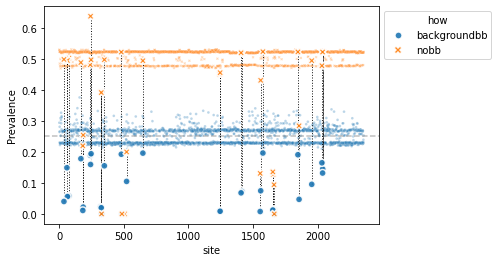

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

dfx["site"] = dfx["site"].astype(int)  # Ensure site is numeric for proper sorting

# 1. Isolate and filter the sites (same as before)
valid_sites = dfx[dfx["Prevalence"] < 0.2]["site"].unique()
df_filtered = dfx[dfx["site"].isin(valid_sites)]

# 2. Draw the scatterplot
ax = sns.scatterplot(
    data=df_filtered,
    x="site",
    y="Prevalence",
    style="how",
    hue="how",
    s=50,      # Slightly larger dots look better on connected plots
    zorder=2,   # Forces the dots to be drawn ON TOP of the lines
    alpha=0.9,
    linewidth=1.5,
)

sns.scatterplot(
    data=dfx,
    x="site",
    y="Prevalence",
    style="how",
    hue="how",
    s=7,      # Slightly larger dots look better on connected plots
    alpha=0.3,  # Make the background points more transparent
    zorder=-1,  # Forces the dots to be drawn BEHIND the lines
    legend=False,  # Avoid duplicate legends
    ax=ax,
)

# 3. Find the min and max for each site to get our line endpoints
ranges = df_filtered.groupby("site")["Prevalence"].agg(["min", "max"])

# 4. Draw the connecting vertical lines
ax.vlines(
    x=ranges.index,
    ymin=ranges["min"],
    ymax=ranges["max"],
    color="k",
    linestyle=":", # Optional: makes the connection a dashed line
    linewidth=1,   # Optional: makes the line thinner
    alpha=0.9,      # Optional: softens the line color
    zorder=1        # Forces the lines to be drawn BEHIND the dots
)

# 5. Position the legend
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.axhline(0.25, color='gray', linestyle='--', zorder=-1, alpha=0.5)  # Optional: adds a horizontal reference line at y=0.25


In [12]:
bucket = "prq49"
dfs = []
for suffix in [
    # "cryptic-",
    "-nobb",
    "-backgroundbb",
]:
    prefix = ""
    if "step" in bucket:
        step = int(bucket.split("-step")[-1]) + 1
    else:
        step = 0
    if "restint" in bucket:
        kind = bucket.split("-")[3]
    else:
        kind = None
    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    for stint in tqdm([100]):
        try:
            series_profiles, = bucket_handle.objects.filter(
                Prefix=f'endeavor=16/{prefix}control-competitions-highestroot{suffix}/stage=4+what=collated/stint={stint}/',
            )
            import warnings
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
            control_fits_df = get_control_t_distns(bucket, prefix, suffix, 16, stint)
            df = pd.read_csv(
                f's3://{bucket}/{series_profiles.key}',
                compression='xz',
            )
            # df = df[df["Competition Series"] == 16005]
            # df = df.groupby([
            #     "genome variation"
            # ]).mean(numeric_only=True).reset_index()
            df["Stint"] = stint
            df["Series"] = df["Competition Series"]
            dfdigest = "{:x}".format( hash_pandas_object( df ).sum() )
            df = preprocess_competition_fitnesses(df, control_fits_df)
            assert "Series" in df.columns, df.columns

            df = df.copy()
            df["bucket"] = bucket
            df["variant"] = {"cryptic-": "skeleton", "": "wildtype"}[prefix]
            df["how"] = suffix.strip("-") if suffix else "none"
            dfs.append(df)
        except Exception as e:
            print(e)
            print(f"Skipping {bucket=}, {stint=}, {prefix=}")

print(len(dfs), "dataframes loaded")
df = pd.concat(dfs)


  0%|          | 0/1 [00:00<?, ?it/s]

40 competitions to preprocess
1 control fits available


100%|██████████| 1/1 [00:00<00:00,  2.10it/s]

60 competitions to preprocess
1 control fits available
2 dataframes loaded


In [13]:
plt.rcParams['figure.dpi'] = 600
plt.rcParams['savefig.dpi'] = 600


teeplots/viz=subplots+ext=.pdf
teeplots/viz=subplots+ext=.png


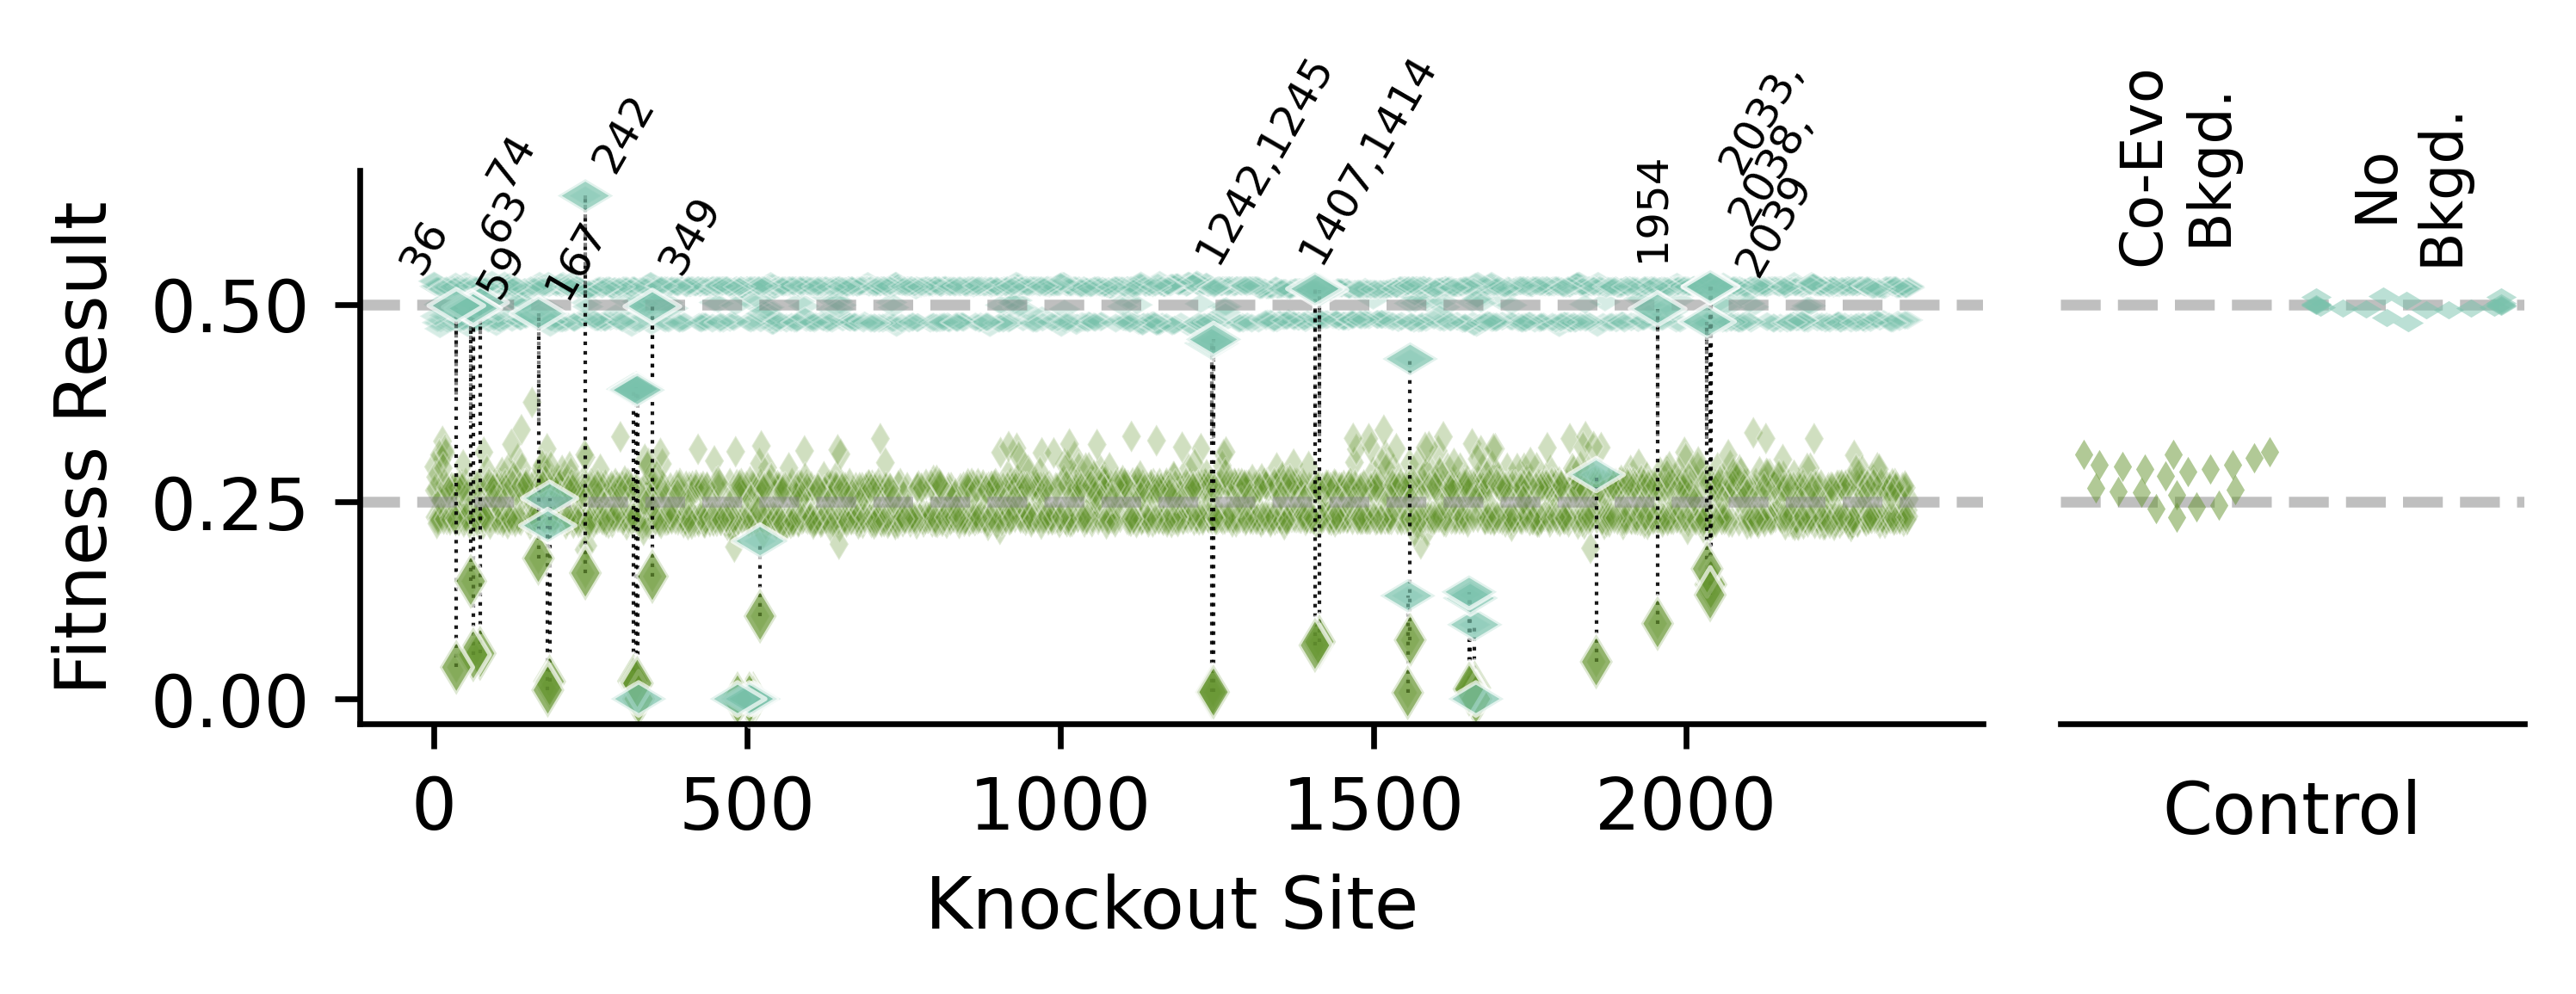

In [14]:
palette = ["#65952f", "#79c2ac"]

with tp.teed(
    plt.subplots,
    1,
    2,
    figsize=(5, 2),
    sharey=True,
    gridspec_kw={"width_ratios": [3.5, 1]},
) as (fig, (ax1, ax2)):
    dfx["site"] = dfx["site"].astype(int)  # Ensure site is numeric for proper sorting

    # 1. Isolate and filter the sites (same as before)
    valid_sites = dfx[dfx["Prevalence"] < 0.25 * 0.75]["site"].unique()
    df_filtered = dfx[dfx["site"].isin(valid_sites)]

    m = MarkerStyle("d")
    m._transform.rotate_deg(90)
    # 2. Draw the scatterplot
    sns.scatterplot(
        data=df_filtered,
        ax=ax1,
        x="site",
        y="Prevalence",
        style="how",
        hue="how",
        s=30,      # Slightly larger dots look better on connected plots
        zorder=2,   # Forces the dots to be drawn ON TOP of the lines
        alpha=0.7,
        linewidth=0.6,
        markers=["d", m],
        legend=False,
        palette=palette,
        clip_on=False,
    )

    sns.scatterplot(
        data=dfx,
        x="site",
        y="Prevalence",
        style="how",
        hue="how",
        s=10,      # Slightly larger dots look better on connected plots
        alpha=0.3,  # Make the background points more transparent
        zorder=-1,  # Forces the dots to be drawn BEHIND the lines
        legend=False,  # Avoid duplicate legends
        ax=ax1,
        palette=palette,
        markers=["d", m],
        clip_on=False,
    )

    # 3. Find the min and max for each site to get our line endpoints
    ranges = df_filtered.groupby("site")["Prevalence"].agg(["min", "max"])

    # 4. Draw the connecting vertical lines
    ax1.vlines(
        x=ranges.index,
        ymin=ranges["min"],
        ymax=ranges["max"],
        color="k",
        linestyle=":", # Optional: makes the connection a dashed line
        linewidth=0.5,   # Optional: makes the line thinner
        alpha=0.9,      # Optional: softens the line color
        zorder=1        # Forces the lines to be drawn BEHIND the dots
    )

    # 5. Position the legend
    ax1.axhline(0.25, color="gray", linestyle="--", zorder=-1, alpha=0.5)  # Optional: adds a horizontal reference line at y=0.25
    ax1.axhline(0.5, color="gray", linestyle="--", zorder=-1, alpha=0.5)  # Optional: adds a horizontal reference line at y=0.25

    how_categories = sorted(df[df["Root ID"] == 0]["how"].dropna().unique())
    swarm_markers = ["d", m]

    # 2. Loop through each category and plot it on ax2
    for i, category in enumerate(how_categories):
        subset = df[(df["Root ID"] == 0) & (df["how"] == category)]

        sns.swarmplot(
            data=subset,
            y="Prevalence",
            x="how",
            order=how_categories,  # Forces Seaborn to maintain the 2-column layout
            marker=swarm_markers[i],
            color=palette[i],      # Applies the exact color from your palette
            s=3,
            alpha=0.5,
            zorder=10,
            ax=ax2,
            legend=False           # Prevents duplicate legend entries
        )

    # 5. Position the legend
    ax2.axhline(0.5, color="gray", linestyle="--", zorder=-1, alpha=0.5)  # Optional: adds a horizontal reference line at y=0.25
    ax2.axhline(0.25, color="gray", linestyle="--", zorder=-1, alpha=0.5)  # Optional: adds a horizontal reference line at y=0.25
    ax1.set_xlabel("Knockout Site")
    ax2.set_xlabel("Control")
    ax2.set_xticks([])
    ax1.set_ylabel("Fitness Result")

    sns.despine(ax=ax1)
    sns.despine(ax=ax2, left=True)
    # sns.move_legend(
    #     ax1, "lower center",
    #     bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
    # )


    focal_sites = [
        36, 59, 63, 74, 167, 242, 349,
        1242, 1245, 1407, 1414, 1954, 2033, 2038, 2039
    ]

    # Get the current bottom limit of the y-axis so the lines start exactly at the bottom
    ymin, _ = ax1.get_ylim()

    focal_sites = [
        36, 59, 63, 74, 167, 242, 349,
        1242, 1245, 1407, 1414, 1954, 2033, 2038, 2039
    ]

    for i, site in enumerate(focal_sites):
        # Find the top of the point for this specific site
        # (Using max() in case a site has multiple points to ensure it starts at the very top)
        point_top = dfx[dfx["site"] == site]["Prevalence"].max()

        # Alternate the end height between 0.3, 0.35, and 0.4 based on the index
        y_target =[0.4, 0.35, 0.3][(i - 1) % 3]

        if site in [1954, 1242, 1245, 1407, 1414]:
            y_target = 0.3
        if site == 36:
            y_target = 0.35
        if site == 59:
            y_target = 0.32
        if site == 63:
            y_target = 0.39
        if site == 74:
            y_target = 0.43
        if site == 167:
            y_target = 0.32
        if site == 242:
            y_target = 0.48
        if site == 349:
            y_target = 0.35

        # Draw a vertical dashed black line from the point up to the staggered height
        ax1.plot(
            [site, site], [point_top, y_target + 0.03],
            color="black",
            linestyle=":",
            linewidth=0.5,
            alpha=0.5,
            zorder=0,
        )

        rotation = 60
        ha="left"
        va="bottom"
        if site in [1407, 1414]:
            if site == 1407:
                site_text = "    1407,1414"
            else:
                site_text = ""
            site = 1330
        elif site in [1242, 1245]:
            if site == 1242:
                site_text = "    1242,1245"
            else:
                site_text = ""
            site = 1242 - 77
        elif site == 1954:
            rotation = 90
            site_text = " " * 4 + str(site)
            ha="center"
            va="bottom"
        elif site == 2033:
            y_target = 0.46
            site_text = f" {site},"
        elif site == 2038:
            y_target = 0.38
            site_text = " " * 2 + str(site) + ","
        elif site == 2039:
            y_target = 0.3
            site_text = " " * 3 + str(site)
        elif site == 36:
            ha = "right"
            site_text = str(site)
        elif site == 74:
            va = "bottom"
            site_text = str(site)
            y_target += 0.03
        else:
            site_text = str(site)


        # Add the text label at the top of the line
        ax1.text(
            x=site,
            y=y_target + 0.18,
            s=f"{site_text}",
            rotation=rotation,
            color="black",
            ha=ha,
            va=va,
            fontsize=6,
            zorder=3
        )

    # Prevent the manual lines from artificially pushing the bottom of the graph down
    ax1.set_ylim(bottom=ymin)

    ax2.text(
        x=0,
        y=0.55,
        s="Co-Evo\nBkgd.",
        rotation=90,
        color="black",
        ha="center",
        va="bottom",
        fontsize=8,
        zorder=3
    )

    ax2.text(
        x=1,
        y=0.55,
        s="No\nBkgd.",
        rotation=90,
        color="black",
        ha="center",
        va="bottom",
        fontsize=8,
        zorder=3
    )

    ax2.yaxis.set_visible(False)

    fig.tight_layout()


# flagged sites summary table


In [15]:
# summarize the fitness prevalence of flagged knockout sites -- i.e. sites
# with a large ("flagged") point in the scatter -- under both experimental
# background conditions (co-evolutionary vs. self). `valid_sites` is the same
# site set selected for large markers in the knockout fitness plot above
condition_labels = {"nobb": "No Bkgd.", "backgroundbb": "Co-Evo Bkgd."}

flagged_sites_table = (
    dfx[dfx["site"].isin(valid_sites)]
    .pivot_table(
        index="site",
        columns="how",
        values="Prevalence",
        aggfunc=["mean", "count"],
    )
    .rename(columns=condition_labels, level=1)
    .sort_index()
)

stat_labels = {"mean": "Mean Prevalence", "count": "n"}
flagged_sites_table.columns = [
    f"{stat_labels[stat]} ({condition})"
    for stat, condition in flagged_sites_table.columns
]
n_cols = [col for col in flagged_sites_table.columns if col.startswith("n (")]
flagged_sites_table[n_cols] = flagged_sites_table[n_cols].astype(int)

flagged_sites_table.round(3)


,Mean Prevalence (Co-Evo Bkgd.),Mean Prevalence (No Bkgd.),n (Co-Evo Bkgd.),n (No Bkgd.)
site,,,,
36,0.040,0.498,1,1
59,0.149,0.497,1,1
63,0.056,0.495,1,1
74,0.058,0.503,1,1
167,0.178,0.488,1,1
182,0.011,0.220,1,1
185,0.022,0.254,1,1
242,0.160,0.638,1,1
319,0.023,0.393,1,1


# flagged sites by condition specificity


In [16]:
# classify flagged sites by which background condition(s) actually drove the
# flag: whether the site's large ("flagged") point in the scatter -- i.e. a row
# below the same threshold used to select large markers in the knockout
# fitness plot above -- came from the eco (co-evolutionary) background, the
# self background, or both
flag_threshold = 0.25 * 0.75  # matches the large-marker selection threshold in the knockout fitness plot

flagged_rows = dfx[
    dfx["site"].isin(valid_sites) & (dfx["Prevalence"] < flag_threshold)
]
flagged_conditions = flagged_rows.groupby("site")["how"].agg(set)

is_flagged_coevo = flagged_sites_table.index.isin(
    [site for site, hows in flagged_conditions.items() if "backgroundbb" in hows]
)
is_flagged_self = flagged_sites_table.index.isin(
    [site for site, hows in flagged_conditions.items() if "focalbb" in hows]
)


## flagged only under self-background


In [17]:
self_only_table = flagged_sites_table[is_flagged_self & ~is_flagged_coevo]
self_only_table.round(3)


,Mean Prevalence (Co-Evo Bkgd.),Mean Prevalence (No Bkgd.),n (Co-Evo Bkgd.),n (No Bkgd.)
site,,,,


## flagged only under eco-background


In [18]:
coevo_only_table = flagged_sites_table[is_flagged_coevo & ~is_flagged_self]
coevo_only_table.round(3)


,Mean Prevalence (Co-Evo Bkgd.),Mean Prevalence (No Bkgd.),n (Co-Evo Bkgd.),n (No Bkgd.)
site,,,,
36,0.040,0.498,1,1
59,0.149,0.497,1,1
63,0.056,0.495,1,1
74,0.058,0.503,1,1
167,0.178,0.488,1,1
182,0.011,0.220,1,1
185,0.022,0.254,1,1
242,0.160,0.638,1,1
319,0.023,0.393,1,1


## flagged under both backgrounds


In [19]:
both_table = flagged_sites_table[is_flagged_coevo & is_flagged_self]
both_table.round(3)


,Mean Prevalence (Co-Evo Bkgd.),Mean Prevalence (No Bkgd.),n (Co-Evo Bkgd.),n (No Bkgd.)
site,,,,
